# 0.Library

In [1]:
# general
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import importlib

# Paths
import sys
sys.path.append('../') 
from features import data_utils as du
from features import data_pipeline as dp
from features import general_func as gf
import constants_data as cd
from features import model_utils as mu

# Reload
importlib.reload(du)
importlib.reload(dp)
importlib.reload(gf)
importlib.reload(cd)
importlib.reload(mu)

<module 'features.model_utils' from '/home/smira/myproject/detection_AD_with_VR_data/src/notebooks/../features/model_utils.py'>

# 1. Paths and Constants

In [2]:
# Read dataframe
parent_folder = Path("../..") # go 2 folder up= "../.."
MSE_models_feature_selection_methods_path = parent_folder / "data" / "model_results" / "model_feature_selection_results.csv"
 
MSE_models_feature_selection_methods = pd.read_csv(MSE_models_feature_selection_methods_path)

MSE_models_feature_selection_methods.head()

,Models\ feature selection method,All 120 features,Select50best,Select20best,Select10best,RFECV,Variance threshold,PCA(5)
0,LinearRegression,31.38,9.77,27.59,NaN,451.36,451.36,5.19
1,Ridge,30.66,8.75,9.29,11.54,49.17,49.17,5.18
2,RandomForestRegressor,6.20,5.94,6.21,5.92,7.92,7.92,6.39
3,XGBRegressor,12.63,13.01,13.22,5.70,14.85,14.85,7.25
4,SVR,6.70,6.80,6.94,6.82,7.03,7.03,6.94


In [3]:
MSE_models_feature_selection_methods.shape

(7, 8)

In [4]:
MSE_models_feature_selection_methods = MSE_models_feature_selection_methods.rename(columns={
    'Models\ feature selection method': "Models"
})
MSE_models_feature_selection_methods.columns

<>:2: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:2: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
/tmp/ipykernel_1018/2953182546.py:2: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  'Models\ feature selection method': "Models"


Index(['Models', 'All 120 features', 'Select50best', 'Select20best',
       'Select10best', 'RFECV', 'Variance threshold', 'PCA(5)'],
      dtype='object')

# Method 1: comparing MSE mean of all models for each feature selection

In [5]:
mean_models_MSE_dict = {"All 120 features" : MSE_models_feature_selection_methods["All 120 features"].mean(),
                   "Select50best" : MSE_models_feature_selection_methods["Select50best"].mean(),
                   "Select20best" : MSE_models_feature_selection_methods["Select20best"].mean(),
                   "Select10best" : MSE_models_feature_selection_methods["Select10best"].mean(),
                   "RFECV" : MSE_models_feature_selection_methods["RFECV"].mean(),
                   "Variance threshold" : MSE_models_feature_selection_methods["Variance threshold"].mean(),
                   "PCA(5)" : (MSE_models_feature_selection_methods["PCA(5)"].mean())}

In [6]:
mean_models_MSE_dict

{'All 120 features': np.float64(35.28666666666667),
 'Select50best': np.float64(28.070000000000004),
 'Select20best': np.float64(31.233333333333334),
 'Select10best': np.float64(30.826),
 'RFECV': np.float64(170.63500000000002),
 'Variance threshold': np.float64(170.63500000000002),
 'PCA(5)': np.float64(25.850000000000005)}

In [7]:
mean_models_MSE_df = pd.DataFrame(mean_models_MSE_dict.items(), columns=['Method', 'MSE Mean']).round(3)
mean_models_MSE_df

,Method,MSE Mean
0,All 120 features,35.287
1,Select50best,28.070
2,Select20best,31.233
3,Select10best,30.826
4,RFECV,170.635
5,Variance threshold,170.635
6,PCA(5),25.850


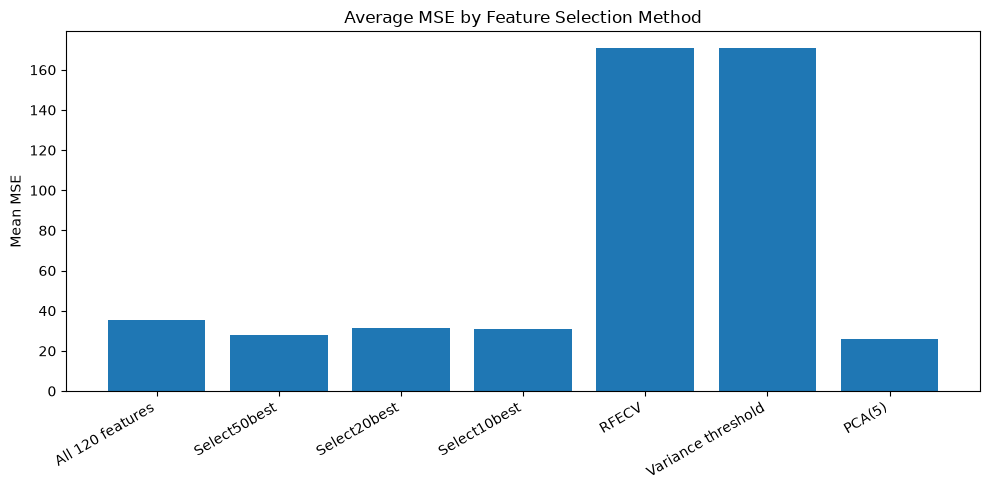

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(mean_models_MSE_df["Method"], mean_models_MSE_df["MSE Mean"])

plt.ylabel("Mean MSE")
plt.title("Average MSE by Feature Selection Method")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

# Method 2: Choose the best method by the lowest MSE for each model

In [9]:
numeric_cols = MSE_models_feature_selection_methods.columns[1:]
MSE_models_feature_selection_methods["Best MSE"] = MSE_models_feature_selection_methods[numeric_cols].min(axis=1)
MSE_models_feature_selection_methods["Best Method"] = MSE_models_feature_selection_methods[numeric_cols].idxmin(axis=1)

/tmp/ipykernel_1018/2593661267.py:3: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  MSE_models_feature_selection_methods["Best Method"] = MSE_models_feature_selection_methods[numeric_cols].idxmin(axis=1)


In [10]:
MSE_models_feature_selection_methods[["Models","Best MSE", "Best Method"]]

,Models,Best MSE,Best Method
0,LinearRegression,5.19,PCA(5)
1,Ridge,5.18,PCA(5)
2,RandomForestRegressor,5.92,Select10best
3,XGBRegressor,5.70,Select10best
4,SVR,6.70,All 120 features
5,LinearSVR,124.15,All 120 features
6,MLPRegressor,NaN,NaN


# Method 3: Heatmap

In [11]:
df_heatmap = MSE_models_feature_selection_methods.drop(columns=["Best Method", "Best MSE"])

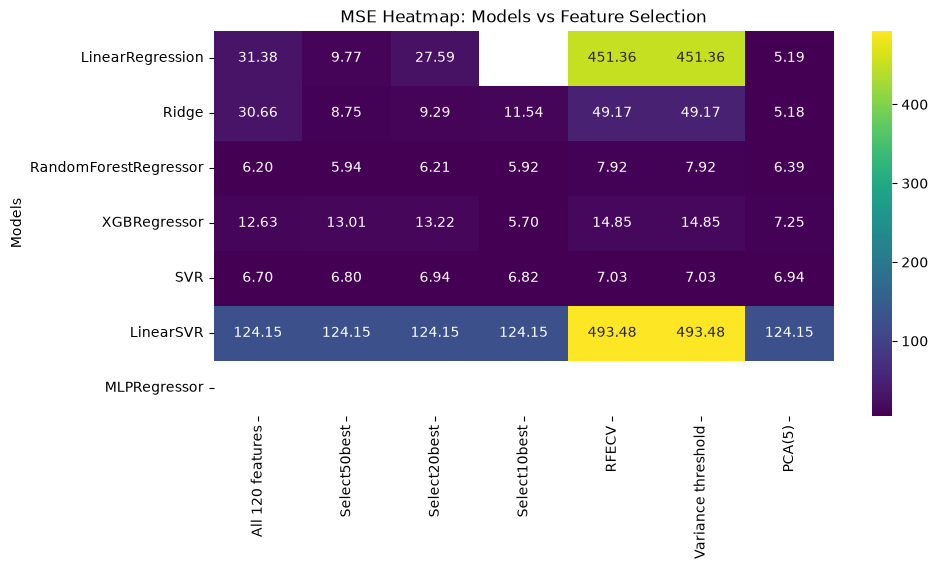

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(
    df_heatmap.set_index("Models"),
    annot=True,   # show values
    fmt=".2f",    # format numbers
    cmap="viridis"  # color style
)

plt.title("MSE Heatmap: Models vs Feature Selection")
plt.show()

# Comparing Target value of 20 young patients without any True MoCA score

In [5]:
# Constants and paths
parent_folder = Path("../..") # go 2 folder up= "../.."
df_path = parent_folder / "data" / "produced_csv" / "4.cleaned_features_20_young_patients_with_target.csv"

preprocessing_folder = parent_folder / "preoduced_csv"

df = pd.read_csv(df_path)

df['Predicted_MoCA']

0     27.152127
1     27.098029
2     27.182443
3     27.100001
4     27.142757
5     27.209877
6     27.229576
7     27.135715
8     27.149004
9     27.124110
10    27.252069
11    27.120115
12    27.088818
13    27.087835
14    27.088628
15    27.088413
16    27.114723
17    27.089856
18    27.274613
19    27.187302
Name: Predicted_MoCA, dtype: float64

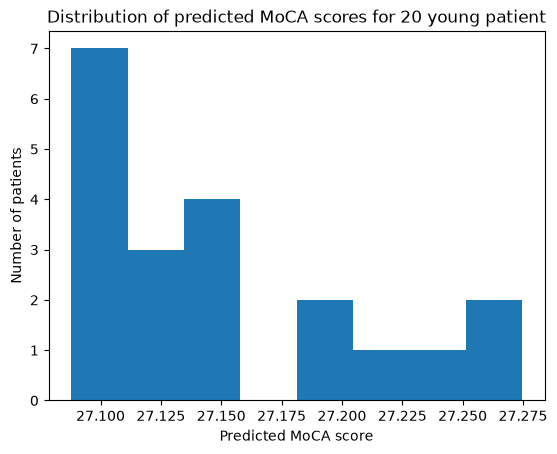

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['Predicted_MoCA'], bins=8)
plt.xlabel("Predicted MoCA score")
plt.ylabel("Number of patients")
plt.title("Distribution of predicted MoCA scores for 20 young patient")
plt.show()